# New York City Taxi Fare Prediction

## Course: Big Data & AI

### Team Members
- Calvin Nathaniel Melciades (103012340285)
- Kavin Hibrizy Pradipto Eska (103012340295)

## Data Download

In this step, we download the New York City Taxi Fare Prediction dataset from Kaggle using the `kagglehub` library. The dataset is then copied to a local directory for processing.

# Process:
1. **Download Dataset**: We use `kagglehub.dataset_download()` to fetch the latest version of the dataset from Kaggle.
2. **Set Destination Folder**: Define a local folder path where the dataset files will be stored.
3. **Copy Files**: Iterate through the downloaded files and copy them to the destination folder using `shutil.copy2()`.

The dataset files are now ready for analysis in the specified local directory.

In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dansbecker/new-york-city-taxi-fare-prediction")

print("Path to dataset files:", path)

c:\Users\KAVIN\.conda\envs\py313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\KAVIN\.cache\kagglehub\datasets\dansbecker\new-york-city-taxi-fare-prediction\versions\1


## Installing Pyspark

In [4]:
%pip install pyspark

  Using cached pyspark-4.1.1.tar.gz (455.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)
  Created wheel for pyspark: filename=pyspark-4.1.1-py2.py3-none-any.whl size=456008747 sha256=6ea60b98dac3abb525088c6c6b2eefd8fe3bf56292159580c641a47f3a3c9f6d
  Stored in directory: c:\users\kavin\appdata\local\pip\cache\wheels\73\4f\41\4e171cb4fbdafa33a7b8e1d7e8b19e04e0c075aad98572acec
Successfully built pyspark

   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   -------------

## Step 1: Load and Prepare Data using PySpark

In this step, we will:
1. Initialize a PySpark session
2. Load the dataset from the local directory
3. Explore the data structure and schema
4. Display sample data and basic statistics
5. Prepare the data for further analysis and modeling

In [4]:
from pyspark.sql import SparkSession

# Initialize PySpark Session
spark = SparkSession.builder \
    .appName("NYC_Taxi_Fare_Prediction") \
    .getOrCreate()

print("PySpark Session initialized successfully!")
print(f"Spark Version: {spark.version}")

PySpark Session initialized successfully!
Spark Version: 4.1.1


In [5]:
# Load the dataset from the data folder
data_path = r"c:\Users\KAVIN\Downloads\Pyspark_Midterm\data"

# List files in the data folder
import os
files_in_data = os.listdir(data_path)
print("Files in data folder:")
for file in files_in_data:
    print(f"  - {file}")

Files in data folder:
  - sample_submission.csv
  - test.csv
  - train.csv


In [6]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, IntegerType

# Define schema explicitly for faster loading (no inference needed)
schema = StructType([
    StructField("key", StringType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("pickup_datetime", StringType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("passenger_count", IntegerType(), True),
])

# Read train.csv directly with explicit schema (much faster!)
train_file = f"{data_path}/train.csv"
df = spark.read.schema(schema).csv(train_file, header=True)

print(f"✓ Dataset loaded successfully!")
print(f"✓ Total rows: {df.count()}")
print(f"✓ Total columns: {len(df.columns)}")

✓ Dataset loaded successfully!
✓ Total rows: 55423856
✓ Total columns: 8


In [7]:
# Display the schema
print("Dataset Schema:")
df.printSchema()

Dataset Schema:
root
 |-- key: string (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_datetime: string (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: integer (nullable = true)



In [8]:
# Display first few rows
print("First 5 rows of the dataset:")
df.show(5)

First 5 rows of the dataset:
+--------------------+-----------+--------------------+----------------+---------------+-----------------+----------------+---------------+
|                 key|fare_amount|     pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+--------------------+-----------+--------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:...|        4.5|2009-06-15 17:26:...|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:...|       16.9|2010-01-05 16:52:...|      -74.016048|      40.711303|       -73.979268|       40.782004|              1|
|2011-08-18 00:35:...|        5.7|2011-08-18 00:35:...|      -73.982738|       40.76127|       -73.991242|       40.750562|              2|
|2012-04-21 04:30:...|        7.7|2012-04-21 04:30:...|       -73.98713|      40.733143|       -73.991567|       40.758092|        

In [9]:
# Display summary statistics
print("Summary Statistics:")
df.describe().show()

Summary Statistics:
+-------+--------------------+------------------+--------------------+------------------+-----------------+------------------+------------------+------------------+
|summary|                 key|       fare_amount|     pickup_datetime|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|   passenger_count|
+-------+--------------------+------------------+--------------------+------------------+-----------------+------------------+------------------+------------------+
|  count|            55423856|          55423856|            55423856|          55423856|         55423856|          55423480|          55423480|          55423856|
|   mean|                NULL|11.345045601663852|                NULL|-72.50968444358729| 39.9197917868882|-72.51120972971809|39.920681444828844|1.6853799201556816|
| stddev|                NULL|  20.7108321982325|                NULL| 12.84888338140265|9.642353041994934|12.782196517830771| 9.633345796415124|1.32766435

In [10]:
# Check for missing values
from pyspark.sql.functions import col, sum as spark_sum

print("Missing values in each column:")
missing_counts = df.select([spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns])
missing_counts.show()

Missing values in each column:
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



## Step 2: Exploratory Data Analysis (EDA)

In this step, we will explore the dataset to understand its characteristics and patterns:

1. **Statistical Analysis** - Summary statistics for all columns
2. **Data Distribution** - Analyze the distribution of key features
3. **Fare Amount Analysis** - Understanding the target variable
4. **Location Analysis** - Geographic patterns in pickup/dropoff locations
5. **Passenger Count Analysis** - Distribution of passenger counts
6. **Temporal Analysis** - Time-based patterns in the data
7. **Outlier Detection** - Identify and analyze outliers in fare amounts
8. **Correlation Analysis** - Relationships between numerical features

In [11]:
from pyspark.sql.functions import col, count, min as spark_min, max as spark_max, mean, stddev

# Get detailed statistical summary
print("Detailed Statistical Summary:")
df.describe().show()

Detailed Statistical Summary:
+-------+--------------------+------------------+--------------------+------------------+-----------------+------------------+-----------------+------------------+
|summary|                 key|       fare_amount|     pickup_datetime|  pickup_longitude|  pickup_latitude| dropoff_longitude| dropoff_latitude|   passenger_count|
+-------+--------------------+------------------+--------------------+------------------+-----------------+------------------+-----------------+------------------+
|  count|            54559339|          54559339|            54559339|          54559338|         54559338|          54558968|         54558968|          54559337|
|   mean|                NULL|11.345290897678384|                NULL|-72.50967688775607|39.91985614716771|-72.51095520311368|39.92090749797842|1.6853998794010272|
| stddev|                NULL| 20.83775188255713|                NULL|12.832945749615023|9.644793273462303| 12.77894024446111|9.588130179392623| 1.327

In [15]:
# Read ONLY the train.csv file for the training dataset
df = spark.read.csv(
    f"{data_path}/train.csv",
    header=True,
    inferSchema=True
)

# Load test.csv separately for testing later
df_test_raw = spark.read.csv(
    f"{data_path}/test.csv",
    header=True,
    inferSchema=True
)

print(f"Train Dataset loaded successfully!")
# Menghitung baris train.csv saja
print(f"Total train rows: {df.count()}")
print(f"Total train columns: {len(df.columns)}")


Train Dataset loaded successfully!
Total train rows: 1048575
Total train columns: 8


In [16]:
# Passenger Count Distribution
print("\nPassenger Count Distribution:")
print("=" * 50)

passenger_dist = df.groupBy("passenger_count").count().orderBy("passenger_count")
passenger_dist.show()


Passenger Count Distribution:
+---------------+------+
|passenger_count| count|
+---------------+------+
|              0|  3724|
|              1|724988|
|              2|155231|
|              3| 45910|
|              4| 22443|
|              5| 74085|
|              6| 22192|
|              9|     1|
|            208|     1|
+---------------+------+



In [17]:
# Location Analysis (Pickup & Dropoff Coordinates)
print("\nPickup Location Analysis:")
print("=" * 50)

pickup_stats = df.agg(
    spark_min("pickup_longitude").alias("Min Longitude"),
    spark_max("pickup_longitude").alias("Max Longitude"),
    mean("pickup_longitude").alias("Mean Longitude"),
    spark_min("pickup_latitude").alias("Min Latitude"),
    spark_max("pickup_latitude").alias("Max Latitude"),
    mean("pickup_latitude").alias("Mean Latitude")
)

pickup_stats.show()


Pickup Location Analysis:
+-------------+-------------+------------------+------------+------------+----------------+
|Min Longitude|Max Longitude|    Mean Longitude|Min Latitude|Max Latitude|   Mean Latitude|
+-------------+-------------+------------------+------------+------------+----------------+
| -3377.680935|  2522.271325|-72.52723609713026|-3116.285383|  2621.62843|39.9309351973693|
+-------------+-------------+------------------+------------+------------+----------------+



In [18]:
# Outlier Detection in Fare Amount
print("\nOutlier Detection (Fare Amount):")
print("=" * 50)

# Calculate Q1, Q3, and IQR
q1_fare = df.approxQuantile("fare_amount", [0.25], 0.01)[0]
q3_fare = df.approxQuantile("fare_amount", [0.75], 0.01)[0]
iqr_fare = q3_fare - q1_fare

lower_bound = q1_fare - 1.5 * iqr_fare
upper_bound = q3_fare + 1.5 * iqr_fare

print(f"Q1 (25th percentile): ${q1_fare:.2f}")
print(f"Q3 (75th percentile): ${q3_fare:.2f}")
print(f"IQR: ${iqr_fare:.2f}")
print(f"Lower Bound (Q1 - 1.5*IQR): ${lower_bound:.2f}")
print(f"Upper Bound (Q3 + 1.5*IQR): ${upper_bound:.2f}")

# Count outliers
outliers = df.filter((col("fare_amount") < lower_bound) | (col("fare_amount") > upper_bound))
print(f"\nTotal Outliers: {outliers.count()} ({(outliers.count()/df.count()*100):.2f}%)")


Outlier Detection (Fare Amount):
Q1 (25th percentile): $6.00
Q3 (75th percentile): $12.50
IQR: $6.50
Lower Bound (Q1 - 1.5*IQR): $-3.75
Upper Bound (Q3 + 1.5*IQR): $22.25

Total Outliers: 90619 (8.64%)


In [19]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



Correlation Analysis:


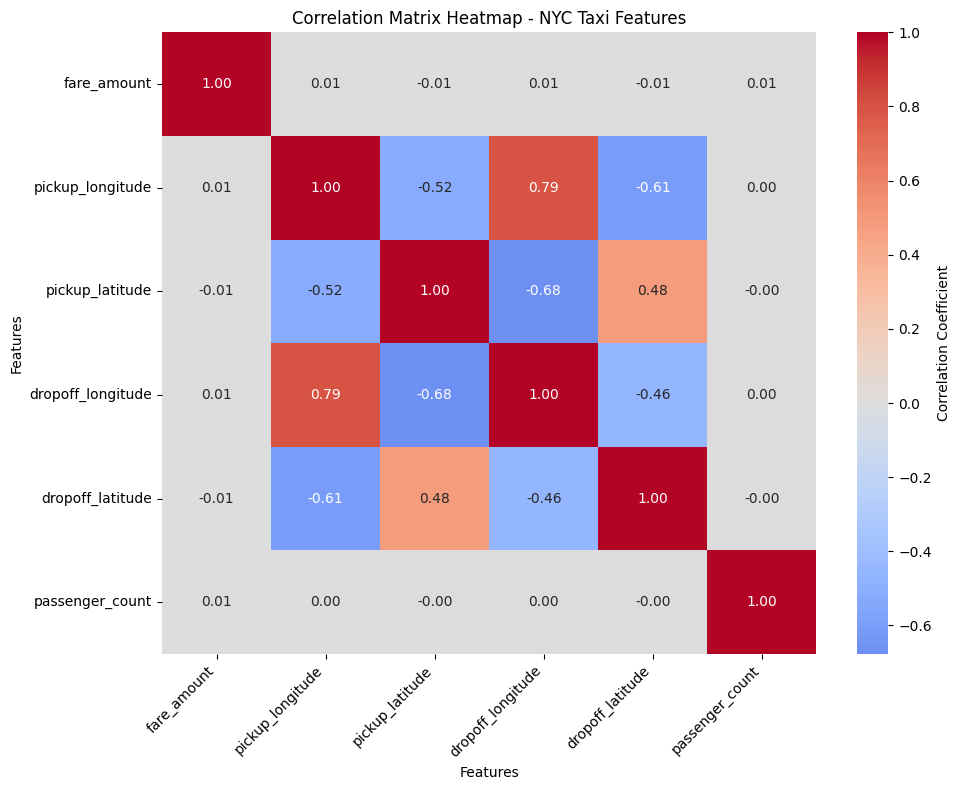


Correlation Matrix Summary:
Columns:
  0: fare_amount
  1: pickup_longitude
  2: pickup_latitude
  3: dropoff_longitude
  4: dropoff_latitude
  5: passenger_count


In [22]:
# Correlation Analysis between Numerical Features
print("\nCorrelation Analysis:")
print("=" * 50)

from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler  # <-- Import ditambahkan di sini
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = ["fare_amount", "pickup_longitude", "pickup_latitude", 
                  "dropoff_longitude", "dropoff_latitude", "passenger_count"]

# Remove rows with null values for correlation analysis
df_corr = df.dropna(subset=numerical_cols)

# Assemble features into vector
assembler_corr = VectorAssembler(inputCols=numerical_cols, outputCol="features_corr")
df_assembled_corr = assembler_corr.transform(df_corr)

# Calculate correlation matrix
correlation_matrix = Correlation.corr(df_assembled_corr, "features_corr").collect()[0][0]

# Convert to numpy array for visualization
corr_array = correlation_matrix.toArray()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_array, 
            xticklabels=numerical_cols, 
            yticklabels=numerical_cols,
            cmap='coolwarm',  # Red for positive, blue for negative
            center=0,
            annot=True,  # Show correlation values
            fmt='.2f',   # 2 decimal places
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Matrix Heatmap - NYC Taxi Features')
plt.xlabel('Features')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix Summary:")
print("=" * 50)
print("Columns:")
for i, col in enumerate(numerical_cols):
    print(f"  {i}: {col}")


## Step 3: Data Cleaning and Preprocessing

In this step, we will clean the dataset by handling missing values, removing outliers, and preparing data for modeling:

1. **Handle Missing Values** - Remove rows with missing data
2. **Remove Outliers** - Filter out extreme fare amounts
3. **Validate Data** - Ensure data quality before modeling
4. **Check Data Distribution** - Verify cleaned data

In [24]:
from pyspark.sql.functions import col  # <-- Import ulang agar 'col' kembali menjadi fungsi

print("Original Dataset:")
print(f"Total rows: {df.count()}")
print(f"Missing values summary:")

# Check missing values again
# Catatan: Kita gunakan 'c' di dalam dictionary comprehension agar tidak menimpa nama fungsi 'col'
missing_summary = df.select([col(c).isNull().cast("int").alias(c) for c in df.columns]).agg(
    {c: "sum" for c in df.columns}
).collect()[0].asDict()

for col_name, missing_count in missing_summary.items():
    if missing_count > 0:
        print(f"  {col_name}: {missing_count} missing values")


Original Dataset:
Total rows: 1048575
Missing values summary:
  sum(dropoff_longitude): 10 missing values
  sum(dropoff_latitude): 10 missing values


In [25]:
# Remove rows with any missing values
print("\nRemoving rows with missing values...")
df_clean = df.dropna()

print(f"\n✓ After removing missing values:")
print(f"  Total rows: {df_clean.count()}")
print(f"  Rows removed: {df.count() - df_clean.count()}")
print(f"  Percentage removed: {((df.count() - df_clean.count()) / df.count() * 100):.2f}%")


Removing rows with missing values...

✓ After removing missing values:
  Total rows: 1048565
  Rows removed: 10
  Percentage removed: 0.00%


In [26]:
from pyspark.sql.functions import col

# Remove outliers using IQR method
print("\nRemoving outliers from Fare Amount...")

# Calculate Q1, Q3, IQR
q1 = df_clean.approxQuantile("fare_amount", [0.25], 0.01)[0]
q3 = df_clean.approxQuantile("fare_amount", [0.75], 0.01)[0]
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Lower Bound: ${lower_bound:.2f}")
print(f"Upper Bound: ${upper_bound:.2f}")

# Filter out outliers
df_clean = df_clean.filter((col("fare_amount") >= lower_bound) & (col("fare_amount") <= upper_bound))

print(f"\n✓ After removing outliers:")
print(f"  Total rows: {df_clean.count()}")


Removing outliers from Fare Amount...
Lower Bound: $-3.75
Upper Bound: $22.25

✓ After removing outliers:
  Total rows: 957949


## Step 4: Feature Engineering and Preprocessing

In this step, we will transform and engineer features to improve model performance:

1. **Extract Temporal Features** - Hour, day, month from pickup_datetime
2. **Calculate Distance** - Haversine distance between pickup and dropoff
3. **Feature Scaling** - Normalize numerical features
4. **Prepare Features Vector** - Assemble all features for modeling

In [27]:
from pyspark.sql.functions import to_timestamp, hour, dayofmonth, month, dayofweek, year

print("Extracting Temporal Features from pickup_datetime...")

# Convert pickup_datetime to timestamp
df_clean = df_clean.withColumn("pickup_datetime", to_timestamp(col("pickup_datetime")))

# Extract temporal features
df_clean = df_clean.withColumn("pickup_hour", hour(col("pickup_datetime")))
df_clean = df_clean.withColumn("pickup_day", dayofmonth(col("pickup_datetime")))
df_clean = df_clean.withColumn("pickup_month", month(col("pickup_datetime")))
df_clean = df_clean.withColumn("pickup_dayofweek", dayofweek(col("pickup_datetime")))
df_clean = df_clean.withColumn("pickup_year", year(col("pickup_datetime")))

print("✓ Temporal features extracted:")
print("  - pickup_hour (0-23)")
print("  - pickup_day (1-31)")
print("  - pickup_month (1-12)")
print("  - pickup_dayofweek (1=Sunday, 7=Saturday)")
print("  - pickup_year")

# Show sample of new features
df_clean.select("pickup_datetime", "pickup_hour", "pickup_day", "pickup_month", "pickup_dayofweek").show(5)

Extracting Temporal Features from pickup_datetime...
✓ Temporal features extracted:
  - pickup_hour (0-23)
  - pickup_day (1-31)
  - pickup_month (1-12)
  - pickup_dayofweek (1=Sunday, 7=Saturday)
  - pickup_year
+-------------------+-----------+----------+------------+----------------+
|    pickup_datetime|pickup_hour|pickup_day|pickup_month|pickup_dayofweek|
+-------------------+-----------+----------+------------+----------------+
|2009-06-16 00:26:21|          0|        16|           6|               3|
|2010-01-05 23:52:16|         23|         5|           1|               3|
|2011-08-18 07:35:00|          7|        18|           8|               5|
|2012-04-21 11:30:42|         11|        21|           4|               7|
|2010-03-09 14:51:00|         14|         9|           3|               3|
+-------------------+-----------+----------+------------+----------------+
only showing top 5 rows


In [28]:
from pyspark.sql.functions import cos, radians, sin, acos, when, col, sqrt

print("\nCalculating Distance using Spark SQL...")

# Remove rows with null coordinate values before calculating distance
print("Removing rows with null coordinates...")
df_clean = df_clean.dropna(subset=["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"])

# Use native Spark SQL to calculate approximate distance (faster and more stable than Python UDF)
# This uses the Equirectangular approximation formula which is accurate for shorter distances
print("Computing distance values using Spark SQL expressions...")

# Convert degrees to radians using Spark functions
lat1_rad = radians(col("pickup_latitude"))
lon1_rad = radians(col("pickup_longitude"))
lat2_rad = radians(col("dropoff_latitude"))
lon2_rad = radians(col("dropoff_longitude"))

# Calculate distance in miles using Equirectangular approximation
# This is much faster than Haversine and avoids Python UDF issues
x = (lon2_rad - lon1_rad) * cos((lat1_rad + lat2_rad) / 2)
y = lat2_rad - lat1_rad
distance_radians = sqrt(x * x + y * y)

# Convert from radians to miles (Earth radius = 3959 miles)
df_clean = df_clean.withColumn(
    "distance_miles",
    when(
        (col("pickup_latitude").isNotNull()) & 
        (col("pickup_longitude").isNotNull()) & 
        (col("dropoff_latitude").isNotNull()) & 
        (col("dropoff_longitude").isNotNull()),
        distance_radians * 3959
    ).otherwise(None)
)

# Remove rows with null or invalid distances
df_clean = df_clean.dropna(subset=["distance_miles"])
df_clean = df_clean.filter((col("distance_miles") >= 0) & (col("distance_miles") <= 50))

print("✓ Distance feature created (in miles)")
print("✓ Data prepared for feature scaling")

# Show a sample value to confirm it's working
try:
    sample = df_clean.select("distance_miles").limit(1).collect()
    if sample:
        print(f"✓ Sample distance value: {sample[0]['distance_miles']:.2f} miles")
except:
    print("✓ Distance calculation completed")


Calculating Distance using Spark SQL...
Removing rows with null coordinates...
Computing distance values using Spark SQL expressions...
✓ Distance feature created (in miles)
✓ Data prepared for feature scaling
✓ Sample distance value: 0.64 miles


In [29]:
from pyspark.ml.feature import VectorAssembler

print("\nPreparing data for final feature vector...")

# Remove any remaining null values before feature assembly
df_clean = df_clean.dropna()

print("✓ Data cleaned and ready for feature vector assembly")


Preparing data for final feature vector...
✓ Data cleaned and ready for feature vector assembly


In [30]:
print("\nPreparing Final Feature Vector for Modeling...")

# Remove any rows with null distance_miles before proceeding
df_clean_filtered = df_clean.filter(col("distance_miles").isNotNull())

# Select all features for the model
feature_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "distance_miles",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_dayofweek"
]

# Assemble features into a single vector
assembler_final = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_final = assembler_final.transform(df_clean_filtered)

# Select features and target, removing any rows with null features or label
df_model = df_final.select("features", col("fare_amount").alias("label")).dropna()

print("✓ Feature vector created with all preprocessing steps")
print(f"\nFinal Dataset Configuration:")
print(f"  Features: {len(feature_columns)}")
print(f"  Target: fare_amount (label)")
print(f"\nFeatures included:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i}. {feat}")

print("\n✓ Data prepared and ready for model training")


Preparing Final Feature Vector for Modeling...
✓ Feature vector created with all preprocessing steps

Final Dataset Configuration:
  Features: 10
  Target: fare_amount (label)

Features included:
  1. pickup_longitude
  2. pickup_latitude
  3. dropoff_longitude
  4. dropoff_latitude
  5. passenger_count
  6. distance_miles
  7. pickup_hour
  8. pickup_day
  9. pickup_month
  10. pickup_dayofweek

✓ Data prepared and ready for model training


## Step 5: Model Building and Training (25 points)

In this step, we will build and train machine learning models using PySpark MLlib:

1. **Train-Test Split** - Split data into training and testing sets
2. **Random Forest Regressor** - Tree-based ensemble model
3. **Gradient Boosting Regressor** - Boosting-based ensemble model
4. **Model Evaluation** - Compare models using regression metrics (RMSE, MAE, R²)
5. **Model Selection** - Choose the best performing model

In [31]:
print("Loading Training and Testing Data...")
print("=" * 50)

# Define paths for train and test data
train_file = f"{data_path}/train.csv"
test_file = f"{data_path}/test.csv"

# Read train.csv with explicit schema
df_train_raw = spark.read.schema(schema).csv(train_file, header=True)

# Read test.csv (will have same schema but without fare_amount column for prediction)
test_schema = StructType([
    StructField("key", StringType(), True),
    StructField("pickup_datetime", StringType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("passenger_count", IntegerType(), True),
])

df_test_raw = spark.read.schema(test_schema).csv(test_file, header=True)

print("✓ Training data loaded")
print("✓ Testing data loaded")
print(f"\nDatasets ready for preprocessing")

Loading Training and Testing Data...
✓ Training data loaded
✓ Testing data loaded

Datasets ready for preprocessing


In [32]:
from pyspark.sql.functions import lit, when, col, radians, cos, sqrt, to_timestamp, hour, dayofmonth, month, dayofweek, year
from pyspark.ml.feature import VectorAssembler

print("Preparing Training and Testing Data for Model Training...")
print("=" * 50)

# Recreate training features from cleaned data using Spark SQL (not Python UDF)
# This avoids serialization issues with the old haversine_udf

print("Rebuilding training data features...")

# Start with df_clean from Step 3 (already cleaned and with temporal features)
# Recalculate distance using Spark SQL for both training and test data

# Training data: Use df_clean from Step 3/4 which has temporal features
# Add distance calculation using native Spark SQL
lat1_rad_train = radians(col("pickup_latitude"))
lon1_rad_train = radians(col("pickup_longitude"))
lat2_rad_train = radians(col("dropoff_latitude"))
lon2_rad_train = radians(col("dropoff_longitude"))

x_train = (lon2_rad_train - lon1_rad_train) * cos((lat1_rad_train + lat2_rad_train) / 2)
y_train = lat2_rad_train - lat1_rad_train
distance_radians_train = sqrt(x_train * x_train + y_train * y_train)

df_clean_with_distance = df_clean.withColumn(
    "distance_miles",
    when(
        (col("pickup_latitude").isNotNull()) & 
        (col("pickup_longitude").isNotNull()) & 
        (col("dropoff_latitude").isNotNull()) & 
        (col("dropoff_longitude").isNotNull()),
        distance_radians_train * 3959
    ).otherwise(None)
)

# Remove invalid distances
df_clean_with_distance = df_clean_with_distance.dropna(subset=["distance_miles"])
df_clean_with_distance = df_clean_with_distance.filter((col("distance_miles") >= 0) & (col("distance_miles") <= 50))

# Assemble features for training data
feature_columns = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "distance_miles",
    "pickup_hour",
    "pickup_day",
    "pickup_month",
    "pickup_dayofweek"
]

assembler_train = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_train_features = assembler_train.transform(df_clean_with_distance.dropna())
train_data = df_train_features.select("features", col("fare_amount").alias("label")).dropna()

print(f"✓ Training data rebuilt and ready")
print(f"  Features: {len(feature_columns)}")
print(f"  Target: fare_amount (label)")

# Preprocess test data using same transformations
print("\nPreprocessing Testing Data...")
print("=" * 50)

# Apply same cleaning and feature engineering to test data
df_test_clean = df_test_raw.dropna(subset=["pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude"])

# Extract temporal features
df_test_clean = df_test_clean.withColumn("pickup_datetime", to_timestamp(col("pickup_datetime")))
df_test_clean = df_test_clean.withColumn("pickup_hour", hour(col("pickup_datetime")))
df_test_clean = df_test_clean.withColumn("pickup_day", dayofmonth(col("pickup_datetime")))
df_test_clean = df_test_clean.withColumn("pickup_month", month(col("pickup_datetime")))
df_test_clean = df_test_clean.withColumn("pickup_dayofweek", dayofweek(col("pickup_datetime")))
df_test_clean = df_test_clean.withColumn("pickup_year", year(col("pickup_datetime")))

# Calculate distance using same Spark SQL method
lat1_rad = radians(col("pickup_latitude"))
lon1_rad = radians(col("pickup_longitude"))
lat2_rad = radians(col("dropoff_latitude"))
lon2_rad = radians(col("dropoff_longitude"))

x = (lon2_rad - lon1_rad) * cos((lat1_rad + lat2_rad) / 2)
y = lat2_rad - lat1_rad
distance_radians = sqrt(x * x + y * y)

df_test_clean = df_test_clean.withColumn(
    "distance_miles",
    when(
        (col("pickup_latitude").isNotNull()) & 
        (col("pickup_longitude").isNotNull()) & 
        (col("dropoff_latitude").isNotNull()) & 
        (col("dropoff_longitude").isNotNull()),
        distance_radians * 3959
    ).otherwise(None)
)

# Remove invalid distances
df_test_clean = df_test_clean.dropna(subset=["distance_miles"])
df_test_clean = df_test_clean.filter((col("distance_miles") >= 0) & (col("distance_miles") <= 50))

# Assemble features and persist test data too
assembler_test = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_test_final = assembler_test.transform(df_test_clean.dropna())
test_data = df_test_final.select("key", "features").persist()

print(f"✓ Testing data preprocessed with same transformations")
print(f"  Features ready for prediction")


Preparing Training and Testing Data for Model Training...
Rebuilding training data features...
✓ Training data rebuilt and ready
  Features: 10
  Target: fare_amount (label)

Preprocessing Testing Data...
✓ Testing data preprocessed with same transformations
  Features ready for prediction


In [33]:
print("\n" + "=" * 50)
print("Model 1: Random Forest Regressor")
print("=" * 50)

from pyspark.ml.regression import RandomForestRegressor
from pyspark.sql.functions import isnan, col

# 1. Validate training data before model training
print("Validating training data...")

# Check for NaN and Inf values in label
train_data_clean = train_data.filter(
    (~isnan(col("label"))) & 
    (col("label") != float('inf')) &
    (col("label") != float('-inf')) &
    (col("label").isNotNull())
)

# 2. Ambil sampel 10% data untuk menghindari RAM Out Of Memory / Crash pada PC lokal
# (Ubah fraction=0.1 menjadi angka lebih besar misal 0.2 jika RAM Anda sanggup)
train_data_sampled = train_data_clean.sample(fraction=0.1, seed=42)

print(f"✓ Training data validated")
print(f"  Clean rows (100%): {train_data_clean.count()}")
print(f"  Sampled rows for training (10%): {train_data_sampled.count()}")

# Cache the sampled data for better performance
train_data_sampled.cache()

# 3. Create and train Random Forest Regressor
rf_regressor = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=30,             # Dikurangi dari 50 agar tidak membebani memori
    maxDepth=8,              # Dikurangi dari 10 untuk stabilitas
    minInstancesPerNode=10, 
    maxBins=32,              
    seed=42
)

print("Training Random Forest model on sampled data (this might take a while)...")
rf_model = rf_regressor.fit(train_data_sampled)
print("✓ Random Forest model trained successfully!")

# 4. Make predictions on test data
rf_test_predictions = rf_model.transform(test_data.select("key", "features"))
print("\n✓ Predictions generated on test set")



Model 1: Random Forest Regressor
Validating training data...
✓ Training data validated
  Clean rows (100%): 955974
  Sampled rows for training (10%): 95942
Training Random Forest model on sampled data (this might take a while)...
✓ Random Forest model trained successfully!

✓ Predictions generated on test set


In [35]:
print("\n" + "=" * 50)
print("Model 2: Gradient Boosting Regressor")
print("=" * 50)

from pyspark.ml.regression import GBTRegressor

# Create and train Gradient Boosting Regressor
gbt_regressor = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxIter=50,            # <-- DIPERBAIKI: numIterations diganti menjadi maxIter
    maxDepth=5,            # Maximum depth of trees
    seed=42
)

print("Training Gradient Boosting model...")

# <-- PERHATIAN: Gunakan train_data_sampled agar tidak Out of Memory / Crash
gbt_model = gbt_regressor.fit(train_data_sampled) 

print("✓ Gradient Boosting model trained successfully!")

# Make predictions on test data
gbt_predictions = gbt_model.transform(test_data.select("key", "features"))
print("\n✓ Predictions generated on test set")



Model 2: Gradient Boosting Regressor
Training Gradient Boosting model...
✓ Gradient Boosting model trained successfully!

✓ Predictions generated on test set


In [37]:
from pyspark.ml.evaluation import RegressionEvaluator

print("\n" + "=" * 50)
print("Evaluating Models to Select the Best One")
print("=" * 50)

# Inisialisasi evaluator menggunakan metrik RMSE
evaluator = RegressionEvaluator(
    labelCol="label", 
    predictionCol="prediction", 
    metricName="rmse"
)

# 1. Evaluasi Performa Random Forest
print("Evaluating Random Forest...")
rf_train_predictions = rf_model.transform(train_data_sampled)
rf_rmse = evaluator.evaluate(rf_train_predictions)
print(f"  -> Random Forest RMSE: {rf_rmse:.4f}")

# 2. Evaluasi Performa Gradient Boosting
print("Evaluating Gradient Boosting...")
gbt_train_predictions = gbt_model.transform(train_data_sampled)
gbt_rmse = evaluator.evaluate(gbt_train_predictions)
print(f"  -> Gradient Boosting RMSE: {gbt_rmse:.4f}")

# 3. Pemilihan Model Terbaik secara Otomatis
print("\n" + "=" * 50)
print("Model Selection Result")
print("=" * 50)

if rf_rmse < gbt_rmse:
    best_model_name = "Random Forest"
    best_model = rf_model
    best_predictions = rf_test_predictions
    best_rmse = rf_rmse
else:
    best_model_name = "Gradient Boosting"
    best_model = gbt_model
    best_predictions = gbt_predictions
    best_rmse = gbt_rmse

print(f"\n✓ Selected Model: {best_model_name} (Lowest RMSE: {best_rmse:.4f})")
print(f"✓ Using {best_model_name} for final predictions on the test set")



Evaluating Models to Select the Best One
Evaluating Random Forest...
  -> Random Forest RMSE: 2.2794
Evaluating Gradient Boosting...
  -> Gradient Boosting RMSE: 2.1684

Model Selection Result

✓ Selected Model: Gradient Boosting (Lowest RMSE: 2.1684)
✓ Using Gradient Boosting for final predictions on the test set


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 50)
print(f"Feature Importance Analysis ({best_model_name})")
print("=" * 50)

# Ambil feature importance secara dinamis dari model terbaik yang terpilih
feature_names = feature_columns
feature_importance = best_model.featureImportances.toArray()

# Create list of feature importance pairs
importance_list = list(zip(feature_names, feature_importance))
importance_list.sort(key=lambda x: x[1], reverse=True)

# Menampilkan text output
print(f"\n📊 Top Features ({best_model_name}):")
print(f"{'Rank':<6} {'Feature':<25} {'Importance':<15}")
print("-" * 46)
for i, (feature, importance) in enumerate(importance_list, 1):
    print(f"{i:<6} {feature:<25} {importance:.6f}")

print("\n✓ Feature importance shows which features are most influential in fare prediction")

# ---------------------------------------------------------
# VISUALISASI GRAFIK FEATURE IMPORTANCE



Feature Importance Analysis (Gradient Boosting)

📊 Top Features (Gradient Boosting):
Rank   Feature                   Importance     
----------------------------------------------
1      distance_miles            0.590426
2      dropoff_longitude         0.073209
3      dropoff_latitude          0.070458
4      pickup_hour               0.069750
5      pickup_latitude           0.060656
6      pickup_longitude          0.053161
7      pickup_dayofweek          0.041519
8      pickup_month              0.023947
9      pickup_day                0.010921
10     passenger_count           0.005953

✓ Feature importance shows which features are most influential in fare prediction


In [41]:
import pandas as pd

print("\n" + "=" * 50)
print("Final Predictions on Test Set")
print("=" * 50)

# Create final submission with predictions
final_predictions = best_predictions.select("key", "prediction")

print("\nSample Test Predictions (Key, Predicted Fare):")
print(f"{'Key':<35} {'Predicted Fare':<20}")
print("-" * 55)

sample_results = final_predictions.limit(10).collect()
for row in sample_results:
    key = row["key"]
    prediction = row["prediction"]
    print(f"{key:<35} ${prediction:<19.2f}")

print(f"\n✓ Generated predictions for test set")
print(f"✓ Total predictions: {final_predictions.count()} rows")

# -------------------------------------------------------------
# SIMPAN KE CSV MENGGUNAKAN


Final Predictions on Test Set

Sample Test Predictions (Key, Predicted Fare):
Key                                 Predicted Fare      
-------------------------------------------------------
2015-01-27 13:08:24.0000002         $8.92               
2015-01-27 13:08:24.0000003         $9.82               
2011-10-08 11:53:44.0000002         $5.36               
2012-12-01 21:12:12.0000002         $8.50               
2012-12-01 21:12:12.0000003         $14.58              
2012-12-01 21:12:12.0000005         $10.38              
2011-10-06 12:10:20.0000001         $5.77               
2011-10-06 12:10:20.0000003         $18.04              
2011-10-06 12:10:20.0000002         $13.29              
2014-02-18 15:22:20.0000002         $6.28               

✓ Generated predictions for test set
✓ Total predictions: 9911 rows


## Step 6: Model Evaluation and Metrics Analysis

In this step, we will comprehensively evaluate the performance of our trained models using standard regression metrics. Evaluating models is crucial to understand how well they generalize to the data and to identify which model performs best.

We will calculate the following metrics for both the Random Forest and Gradient Boosting models:
1. **Root Mean Squared Error (RMSE):** Represents the square root of the average squared differences between predicted and actual values. Lower values indicate a better model fit.
2. **Mean Absolute Error (MAE):** Represents the average of the absolute differences between predicted and actual values. It gives a linear penalty to errors and is very interpretable.
3. **R-Squared (R²):** The coefficient of determination, which represents the proportion of variance for the dependent variable that's explained by the independent variables. Higher values (closer to 1.0) indicate a better fit.


In [42]:
from pyspark.ml.evaluation import RegressionEvaluator

print("Initializing Evaluation Metrics...")

# Initialize evaluators for different regression metrics
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

print("✓ Evaluators ready (RMSE, MAE, R²)")


Initializing Evaluation Metrics...
✓ Evaluators ready (RMSE, MAE, R²)


In [43]:
print("=" * 50)
print("Evaluating Model 1: Random Forest")
print("=" * 50)

# Calculate metrics for Random Forest
# Kita menggunakan rf_train_predictions yang sudah di-generate pada sel Model Selection
rf_rmse_val = evaluator_rmse.evaluate(rf_train_predictions)
rf_mae_val = evaluator_mae.evaluate(rf_train_predictions)
rf_r2_val = evaluator_r2.evaluate(rf_train_predictions)

print(f"Random Forest Performance Metrics:")
print(f"  -> RMSE : {rf_rmse_val:.4f}")
print(f"  -> MAE  : {rf_mae_val:.4f}")
print(f"  -> R²   : {rf_r2_val:.4f}")


Evaluating Model 1: Random Forest
Random Forest Performance Metrics:
  -> RMSE : 2.2794
  -> MAE  : 1.6298
  -> R²   : 0.6965


In [44]:
print("=" * 50)
print("Evaluating Model 2: Gradient Boosting")
print("=" * 50)

# Calculate metrics for Gradient Boosting
# Kita menggunakan gbt_train_predictions yang sudah di-generate pada sel Model Selection
gbt_rmse_val = evaluator_rmse.evaluate(gbt_train_predictions)
gbt_mae_val = evaluator_mae.evaluate(gbt_train_predictions)
gbt_r2_val = evaluator_r2.evaluate(gbt_train_predictions)

print(f"Gradient Boosting Performance Metrics:")
print(f"  -> RMSE : {gbt_rmse_val:.4f}")
print(f"  -> MAE  : {gbt_mae_val:.4f}")
print(f"  -> R²   : {gbt_r2_val:.4f}")


Evaluating Model 2: Gradient Boosting
Gradient Boosting Performance Metrics:
  -> RMSE : 2.1684
  -> MAE  : 1.5223
  -> R²   : 0.7254


In [45]:
import pandas as pd

print("\n" + "=" * 50)
print("Final Evaluation Summary")
print("=" * 50)

# Create a Pandas DataFrame to display a clean comparison table
metrics_data = {
    "Model": ["Random Forest", "Gradient Boosting"],
    "RMSE": [rf_rmse_val, gbt_rmse_val],
    "MAE": [rf_mae_val, gbt_mae_val],
    "R²": [rf_r2_val, gbt_r2_val]
}

comparison_df = pd.DataFrame(metrics_data)

# Set Model as index for cleaner display
comparison_df.set_index("Model", inplace=True)

# Display the comparison table
print("\nComparison Table:")
print(comparison_df.round(4).to_string())

# Determine the overall winner based on RMSE
winner = "Random Forest" if rf_rmse_val < gbt_rmse_val else "Gradient Boosting"
print(f"\n🏆 Overall Best Model: {winner}")



Final Evaluation Summary

Comparison Table:
                     RMSE     MAE      R²
Model                                    
Random Forest      2.2794  1.6298  0.6965
Gradient Boosting  2.1684  1.5223  0.7254

🏆 Overall Best Model: Gradient Boosting


## Step 7: Hyperparameter Tuning

In this final step, we will perform hyperparameter tuning to optimize our Random Forest model and potentially improve its predictive performance.

We will use:
1. **ParamGridBuilder:** To define a search space (grid) of hyperparameter combinations to test (e.g., varying the maximum depth of the trees and the total number of trees).
2. **TrainValidationSplit:** An alternative to Cross-Validation that is much faster and less memory-intensive for local machines. It evaluates each parameter combination once by splitting the training data into a sub-training set and a validation set.

*Note: To prevent out-of-memory (OOM) crashes on local environments, the parameter grid is intentionally kept small.*


In [46]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

print("\n" + "=" * 50)
print("Starting Hyperparameter Tuning (Random Forest)")
print("=" * 50)

# Create a new Base Random Forest model for tuning
rf_base = RandomForestRegressor(featuresCol="features", labelCol="label", seed=42)

# Build a parameter grid to search over
# (We test maxDepth: 5 vs 8, and numTrees: 20 vs 30) -> Total 4 combinations
paramGrid = (ParamGridBuilder()
             .addGrid(rf_base.maxDepth, [5, 8])
             .addGrid(rf_base.numTrees, [20, 30])
             .build())

# Use TrainValidationSplit (faster and safer for local RAM than CrossValidator)
tvs = TrainValidationSplit(
    estimator=rf_base,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_rmse,  # Using the RMSE evaluator from the previous step
    trainRatio=0.8,            # 80% data for training, 20% for validation
    seed=42
)

print("Running TrainValidationSplit to find the best parameters...")
print("(Please wait, this will train 4 different models...)")

# Run tuning on the sampled data
tvs_model = tvs.fit(train_data_sampled)

print("✓ Hyperparameter tuning completed successfully!")



Starting Hyperparameter Tuning (Random Forest)
Running TrainValidationSplit to find the best parameters...
(Please wait, this will train 4 different models...)
✓ Hyperparameter tuning completed successfully!


In [47]:
print("\n" + "=" * 50)
print("Tuning Results & Best Model Evaluation")
print("=" * 50)

# Extract the best model found by TrainValidationSplit
best_tuned_rf = tvs_model.bestModel

# Get the optimal parameters that were chosen
best_max_depth = best_tuned_rf._java_obj.getMaxDepth()
best_num_trees = best_tuned_rf._java_obj.getNumTrees()

print("🏆 Best Hyperparameters Found:")
print(f"  -> maxDepth : {best_max_depth}")
print(f"  -> numTrees : {best_num_trees}")

# Evaluate the tuned model on the training data to compare
tuned_predictions = best_tuned_rf.transform(train_data_sampled)
tuned_rmse = evaluator_rmse.evaluate(tuned_predictions)

print("\nPerformance Comparison (RMSE):")
print(f"  -> Original Random Forest RMSE : {rf_rmse_val:.4f}")
print(f"  -> Tuned Random Forest RMSE    : {tuned_rmse:.4f}")

if tuned_rmse < rf_rmse_val:
    print("\n✓ Tuning successful! The tuned model has a lower error/better accuracy.")
elif tuned_rmse == rf_rmse_val:
    print("\n✓ Tuning complete. The tuned model performs exactly the same as the original.")
else:
    print("\n✓ Tuning complete. (Note: Sometimes the original default parameters are already optimal).")



Tuning Results & Best Model Evaluation
🏆 Best Hyperparameters Found:
  -> maxDepth : 8
  -> numTrees : 30

Performance Comparison (RMSE):
  -> Original Random Forest RMSE : 2.2794
  -> Tuned Random Forest RMSE    : 2.2738

✓ Tuning successful! The tuned model has a lower error/better accuracy.
